# Testing multiple machine learning approaches.

## Load packages

https://auto.gluon.ai/0.4.0/tutorials/tabular_prediction/tabular-quickstart.html

In [ ]:
%pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor
import pandas as pd
import numpy as np

Connect to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Load the datasets

In [ ]:
train_data2018 = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2018.csv')
train_data2019 = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2019.csv')
train_data2020 = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2020.csv')
train_data2022 = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2022.csv')
train_data2023 = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2023.csv')

frames = [train_data2018, train_data2019, train_data2020, train_data2022, train_data2023]

train_data = pd.concat(frames)

train_data = train_data.drop(columns=['geometry','id','Unnamed: 0'])

#subsample_size = 500  # subsample subset of data for faster demo, try setting this to much larger values
#train_data = train_data.sample(n=subsample_size, random_state=0)
train_data.head()

In [ ]:
label = 'class'
print("Summary of class variable: \n", train_data[label].describe())

In [ ]:
import seaborn as sns
sns.countplot(x=train_data[label])

In [ ]:
print(len(train_data))
train_data = train_data.dropna()
print(len(train_data))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP

# Split labels and embeddings
# The 'class' column contains the labels, and the rest are embeddings
labels = train_data['class']
embeddings = train_data.drop(columns=['class']).values

# Run UMAP
umap = UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding_2d = umap.fit_transform(embeddings)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    "UMAP1": embedding_2d[:, 0],
    "UMAP2": embedding_2d[:, 1],
    "UMAP3": embedding_2d[:, 2],
    "Label": labels.values
})

# Plot
plt.figure(figsize=(8, 6))

for label in sorted(plot_df["Label"].unique()):
    subset = plot_df[plot_df["Label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        s=20,
        alpha=0.7,
        label=str(label)
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Projection of Embeddings")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

for label in sorted(plot_df["Label"].unique()):
    subset = plot_df[plot_df["Label"] == label]
    plt.scatter(
        subset["UMAP1"],
        subset["UMAP3"],
        s=20,
        alpha=0.7,
        label=str(label)
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP Projection of Embeddings")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

for label in sorted(plot_df["Label"].unique()):
    subset = plot_df[plot_df["Label"] == label]
    plt.scatter(
        subset["UMAP2"],
        subset["UMAP3"],
        s=20,
        alpha=0.7,
        label=str(label)
    )

plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP Projection of Embeddings")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Naïve approach: not taking spatial autocorrelation into account.

In [16]:
save_path = '/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/AutoML_AlphaEarth_prediction_output/'  # specifies folder to store trained models
#predictor = TabularPredictor(label=label, path=save_path).fit(train_data,num_gpus=1)
label = 'class'
TabularPredictor(label=label, path=save_path,eval_metric='f1_macro').fit(train_data,calibrate_decision_threshold=True)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       9.69 GB / 12.67 GB (76.5%)
Disk Space Avail:   72.23 GB / 107.72 GB (67.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install aut

In [17]:
test_data = TabularDataset('/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2021.csv')
test_data = test_data.drop(columns=['geometry','id','Unnamed: 0'])
label = 'class'
y_test = test_data[label]  # values to predict
test_data_nolab = test_data.drop(columns=[label])  # delete label column to prove we're not cheating
test_data_nolab.head()

Loaded data from: /content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2021.csv | Columns = 68 / 68 | Rows = 8718 -> 8718


,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,-0.214133,-0.048228,-0.147697,-0.084214,-0.013841,-0.153787,0.192910,-0.010396,0.160000,-0.098424,...,0.284444,-0.153787,-0.059116,-0.084214,-0.066990,-0.179377,-0.048228,-0.172795,-0.048228,0.003937
1,-0.221453,-0.221453,-0.147697,0.044844,-0.059116,-0.186082,0.093564,0.008858,0.166336,-0.153787,...,0.259900,-0.084214,-0.124567,-0.038447,-0.035433,-0.012057,0.130165,-0.079723,-0.007443,-0.147697
2,-0.179377,-0.221453,-0.166336,0.071111,0.013841,-0.244152,0.141730,0.059116,0.147697,-0.084214,...,0.244152,-0.084214,-0.103406,0.066990,-0.108512,-0.041584,0.103406,-0.135886,-0.029773,-0.059116
3,-0.221453,-0.310096,-0.172795,0.029773,0.012057,-0.135886,0.093564,-0.062991,0.135886,-0.135886,...,0.301423,-0.141730,-0.093564,0.022207,-0.038447,-0.071111,0.130165,-0.093564,0.041584,-0.130165
4,-0.221453,-0.147697,-0.160000,-0.044844,0.032541,-0.153787,0.147697,0.029773,0.153787,-0.130165,...,0.276140,-0.124567,-0.066990,-0.059116,-0.066990,-0.108512,0.024606,-0.147697,-0.084214,-0.079723


In [18]:
predictor = TabularPredictor.load(save_path)  # unnecessary, just demonstrates how to load previously-trained predictor from file

y_pred = predictor.predict(test_data_nolab)
print("Predictions:  \n", y_pred)
perf = predictor.evaluate_predictions(y_true=y_test, y_pred=y_pred, auxiliary_metrics=True)

Predictions:  
 0       nograss
1          F1_2
2          F1_2
3          F1_2
4          F1_2
         ...   
8713    nograss
8714    nograss
8715    nograss
8716         F3
8717    nograss
Name: class, Length: 8718, dtype: object


In [19]:
perf

{'f1_macro': 0.47381880111153546,
 'accuracy': 0.5467997247075017,
 'balanced_accuracy': np.float64(0.47808189565565895),
 'mcc': np.float64(0.4063416305302123)}

In [20]:
predictor.leaderboard(test_data, silent=True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.474124,0.618840,f1_macro,0.134625,0.046857,104.042625,0.134625,0.046857,104.042625,1,True,10
1,WeightedEnsemble_L2,0.473819,0.633223,f1_macro,8.543343,2.729588,1037.660428,0.019449,0.005316,1.128110,2,True,12
2,LightGBMXT,0.467500,0.597221,f1_macro,3.284262,0.954672,41.563937,3.284262,0.954672,41.563937,1,True,2
3,CatBoost,0.461313,0.609471,f1_macro,0.284809,0.091043,731.375715,0.284809,0.091043,731.375715,1,True,6
4,LightGBM,0.458896,0.614207,f1_macro,4.628698,1.566757,71.491863,4.628698,1.566757,71.491863,1,True,3
5,XGBoost,0.452371,0.592958,f1_macro,0.833658,0.192473,47.714668,0.833658,0.192473,47.714668,1,True,9
6,NeuralNetFastAI,0.446823,0.621834,f1_macro,0.191499,0.064943,88.058178,0.191499,0.064943,88.058178,1,True,1
7,LightGBMLarge,0.446468,0.594922,f1_macro,3.839982,1.158490,80.899778,3.839982,1.158490,80.899778,1,True,11
8,RandomForestGini,0.428650,0.552359,f1_macro,3.085271,0.305253,68.892686,3.085271,0.305253,68.892686,1,True,4
9,RandomForestEntr,0.420191,0.561194,f1_macro,1.813315,0.561161,89.581251,1.813315,0.561161,89.581251,1,True,5


Prediction probabilities instead of final classes.

In [21]:
pred_probs = predictor.predict_proba(test_data_nolab)
pred_probs.head(5)

,F0,F1_2,F3,F4,F5,nograss
0,0.012175,0.034196,0.013401,0.000228,0.000007,0.939993
1,0.019313,0.756337,0.128726,0.001773,0.000285,0.093565
2,0.064155,0.575725,0.184935,0.000986,0.000242,0.173957
3,0.020005,0.614418,0.075019,0.001501,0.001160,0.287898
4,0.085107,0.690469,0.075188,0.001021,0.000058,0.148156


In [22]:
results = predictor.fit_summary(show_plot=True)

*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val eval_metric  pred_time_val     fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.633223    f1_macro       2.729588  1037.660428                0.005316           1.128110            2       True         12
1       NeuralNetFastAI   0.621834    f1_macro       0.064943    88.058178                0.064943          88.058178            1       True          1
2        NeuralNetTorch   0.618840    f1_macro       0.046857   104.042625                0.046857         104.042625            1       True         10
3              LightGBM   0.614207    f1_macro       1.566757    71.491863                1.566757          71.491863            1       True          3
4              CatBoost   0.609471    f1_macro       0.091043   731.375715                0.091043         731.375715            1       True          6
5            LightGB

In [23]:
print("AutoGluon infers problem type is: ", predictor.problem_type)
print("AutoGluon identified the following types of features:")
print(predictor.feature_metadata)

AutoGluon infers problem type is:  multiclass
AutoGluon identified the following types of features:
('float', []) : 64 | ['A00', 'A01', 'A02', 'A03', 'A04', ...]


In [ ]:
predictor.predict(test_data, model='LightGBM')

,class
0,nograss
1,F1_2
2,F1_2
3,nograss
4,F1_2
...,...
8713,nograss
8714,nograss
8715,nograss
8716,F3


## Maximising predictability

In [ ]:
time_limit = 120  # for quick demonstration only, you should set this to longest time you are willing to wait (in seconds)
metric = 'f1_macro'  # specify your evaluation metric here
predictor2 = TabularPredictor(label, eval_metric=metric).fit(train_data, time_limit=time_limit, presets='best_quality',num_gpus=1) # see 'best_quality', 'high_quality', 'good_quality' or 'medium_quality'
predictor2.leaderboard(test_data, silent=True)


No path specified. Models will be saved in: "AutogluonModels/ag-20260623_114230"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.02 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       7.25 GB / 12.67 GB (57.2%)
Disk Space Avail:   56.00 GB / 112.64 GB (49.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI_BAG_L1,0.501403,0.533719,f1_macro,1.237211,1.069685,58.177198,1.237211,1.069685,58.177198,1,True,1
1,WeightedEnsemble_L3,0.501403,0.533719,f1_macro,1.239561,1.086239,58.202187,0.002349,0.016554,0.024988,3,True,3
2,WeightedEnsemble_L2,0.501403,0.533719,f1_macro,1.239812,1.094058,58.204378,0.002600,0.024373,0.027179,2,True,2


## Confusion matrix

['F0' 'F1_2' 'F3' 'F4' 'F5' 'nograss']
[[ 309  345   71   19    2   65]
 [ 225 1929  223   33   14  273]
 [ 138  843  699  238   43  408]
 [  11   83  215  234    1   58]
 [   1   33   19    1  112   61]
 [  27  270  111   17   51 1536]]


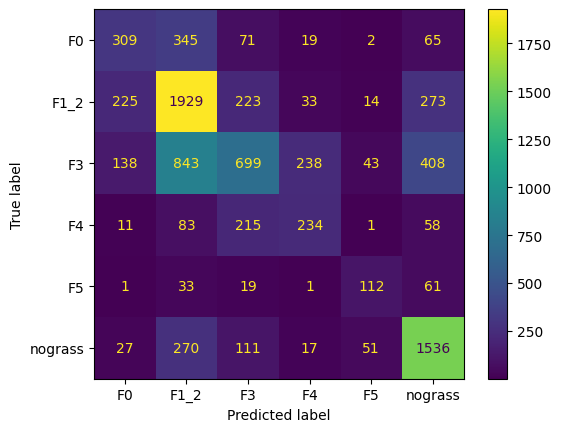

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#pred = predictor2.predict(test_data, model='NeuralNetFastAI_BAG_L1')
#pred2 = predictor2.predict(test_data)
pred = predictor.predict(test_data, model='WeightedEnsemble_L2')

cm = confusion_matrix(y_test, pred)

labels_used = np.unique(np.concatenate([y_test, pred]))
print(labels_used)


print(cm)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels_used)

cm_display.plot()
plt.show()